In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [158]:
# Import data
def import_data(data_name: str):
    """Data importing function for ease of use

    Args:
        data_name (str): Name of the dataset to work with
    """
    if data_name not in ["vahid-linear", "vahid-nonlin", "econ-ML-ex1", "debt-loss", "ADMIT-synthetic"]:
        raise ValueError(f"data_name unrecognized: {data_name}")

    # I ran the debt-loss script later so I need to deal with that
    if data_name == "debt-loss":
        rmses = {
            "uniform_all": pd.read_csv(
                f"../output/11-21/RMSE_table_{data_name}_uniform_all_11-21_18h1m.csv",
                index_col=[0]
            ),
            "quantile_all": pd.read_csv(
                f"../output/11-21/RMSE_table_{data_name}_quantile_all_11-21_18h2m.csv",
                index_col=[0]
            ),
            "uniform_sequential": pd.read_csv(
                f"../output/11-17_to_11-18/RMSE_table_debt_11-18_17h18m.csv",
                index_col=[0]
            ),
            "quantile_sequential": pd.read_csv(
                f"../output/11-17_to_11-18/quantile_RMSE_table_debt_11-18_18h8m.csv",
                index_col=[0]
            )
        }
    else:
        rmses = {
            "uniform_all": pd.read_csv(
                f"../output/11-21/RMSE_table_{data_name}_uniform_all_11-21_15h23m.csv",
                index_col=[0]
            ),
            "quantile_all": pd.read_csv(
                f"../output/11-21/RMSE_table_{data_name}_quantile_all_11-21_15h23m.csv",
                index_col=[0]
            ),
            "uniform_sequential": pd.read_csv(
                f"../output/11-17_to_11-18/RMSE_table_{data_name}_11-18_17h18m.csv",
                index_col=[0]
            ),
            "quantile_sequential": pd.read_csv(
                f"../output/11-17_to_11-18/quantile_RMSE_table_{data_name}_11-18_18h8m.csv",
                index_col=[0]
            )
        }

    return rmses

In [177]:
data_name = "econ-ML-ex1"
rmses = import_data(data_name=data_name)

In [178]:
best_rmse = {}
for data in rmses:
    df = rmses[data]
    df_best = df[df["RMSE"].values == df.min().values]
    N_best = df_best.index.item()
    rmse_best = df_best.values.item()
    best_rmse[f"{data}\n(N_DISC={N_best})"] = rmse_best
    

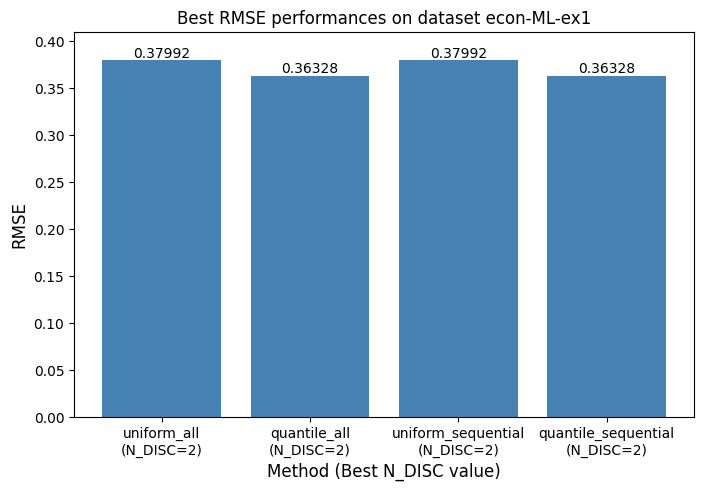

In [179]:
fig = plt.figure(figsize=(8, 5))

for key in best_rmse:
    p = plt.bar(key, best_rmse[key], color="steelblue")
    plt.bar_label(p, label_type="edge")

plt.xlabel("Method (Best N_DISC value)", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.ylim(0, .41)
plt.title(f"Best RMSE performances on dataset {data_name}")

plt.savefig(f"../output/11-21/best_rmse_comparison_{data_name}.png", dpi=300, bbox_inches="tight")

plt.show()